# Cardiac Risk Prediction Model Training & Evaluation

Trains and compares six classifiers on the preprocessed heart disease data (from `preprocessing.ipynb`):

| Model | Features used |
|---|---|
| Logistic Regression | scaled |
| SVM (RBF) | scaled |
| k-Nearest Neighbors | scaled |
| Random Forest | unscaled |
| XGBoost | unscaled |
| ANN (MLPClassifier) | scaled |

**Metrics:** accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, ROC curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('processed/train.csv')
test = pd.read_csv('processed/test.csv')
train_s = pd.read_csv('processed/train_scaled.csv')
test_s = pd.read_csv('processed/test_scaled.csv')

X_train, y_train = train.drop(columns='target'), train['target']
X_test, y_test = test.drop(columns='target'), test['target']
X_train_s, X_test_s = train_s.drop(columns='target'), test_s.drop(columns='target')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (216, 17), Test: (54, 17)


In [2]:
# eval helper
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

results = {}

def evaluate(name, model, X_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Absence', 'Presence']))

## Baseline models

### Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
evaluate('Logistic Regression', log_reg, X_test_s)

=== Logistic Regression ===
              precision    recall  f1-score   support

     Absence       0.93      0.87      0.90        30
    Presence       0.85      0.92      0.88        24

    accuracy                           0.89        54
   macro avg       0.89      0.89      0.89        54
weighted avg       0.89      0.89      0.89        54



### Support Vector Machine (RBF kernel)

In [4]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_s, y_train)
evaluate('SVM', svm, X_test_s)

=== SVM ===
              precision    recall  f1-score   support

     Absence       0.90      0.87      0.88        30
    Presence       0.84      0.88      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.87      0.87        54
weighted avg       0.87      0.87      0.87        54



### k-Nearest Neighbors

First pick k with 5-fold cross-validation on the training set, then evaluate the best k on the test set.

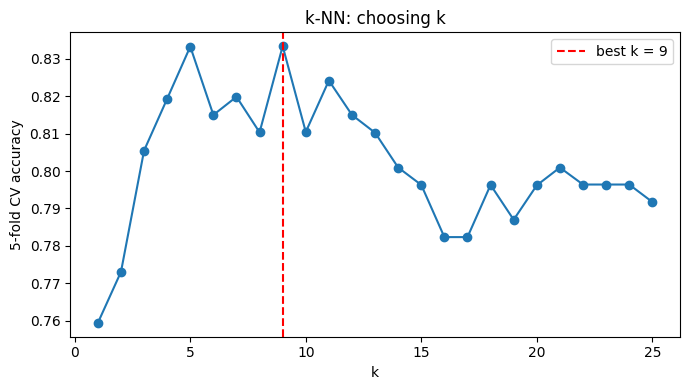

=== k-NN (k=9) ===
              precision    recall  f1-score   support

     Absence       0.89      0.83      0.86        30
    Presence       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1, 26)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train, cv=5).mean()
             for k in k_range]
best_k = k_range[int(np.argmax(cv_scores))]

plt.figure(figsize=(7, 4))
plt.plot(k_range, cv_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('k'); plt.ylabel('5-fold CV accuracy'); plt.title('k-NN: choosing k')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
evaluate(f'k-NN (k={best_k})', knn, X_test_s)

## Advanced models

### Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
evaluate('Random Forest', rf, X_test)

=== Random Forest ===
              precision    recall  f1-score   support

     Absence       0.86      0.80      0.83        30
    Presence       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



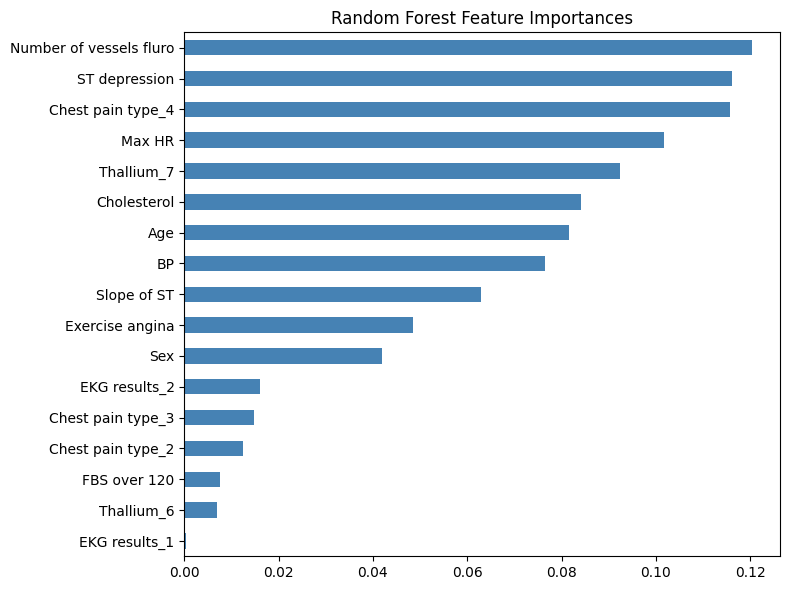

In [7]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importances')
plt.tight_layout(); plt.show()

### XGBoost

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                    eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
evaluate('XGBoost', xgb, X_test)

=== XGBoost ===
              precision    recall  f1-score   support

     Absence       0.86      0.80      0.83        30
    Presence       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



### Artificial Neural Network (MLPClassifier)

A small two-hidden-layer network — appropriate for 216 training samples; anything bigger would overfit.

In [9]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                    alpha=1e-2, max_iter=2000, random_state=42)
ann.fit(X_train_s, y_train)
evaluate('ANN (MLP)', ann, X_test_s)

=== ANN (MLP) ===
              precision    recall  f1-score   support

     Absence       0.86      0.83      0.85        30
    Presence       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



## Model comparison

### Confusion matrices

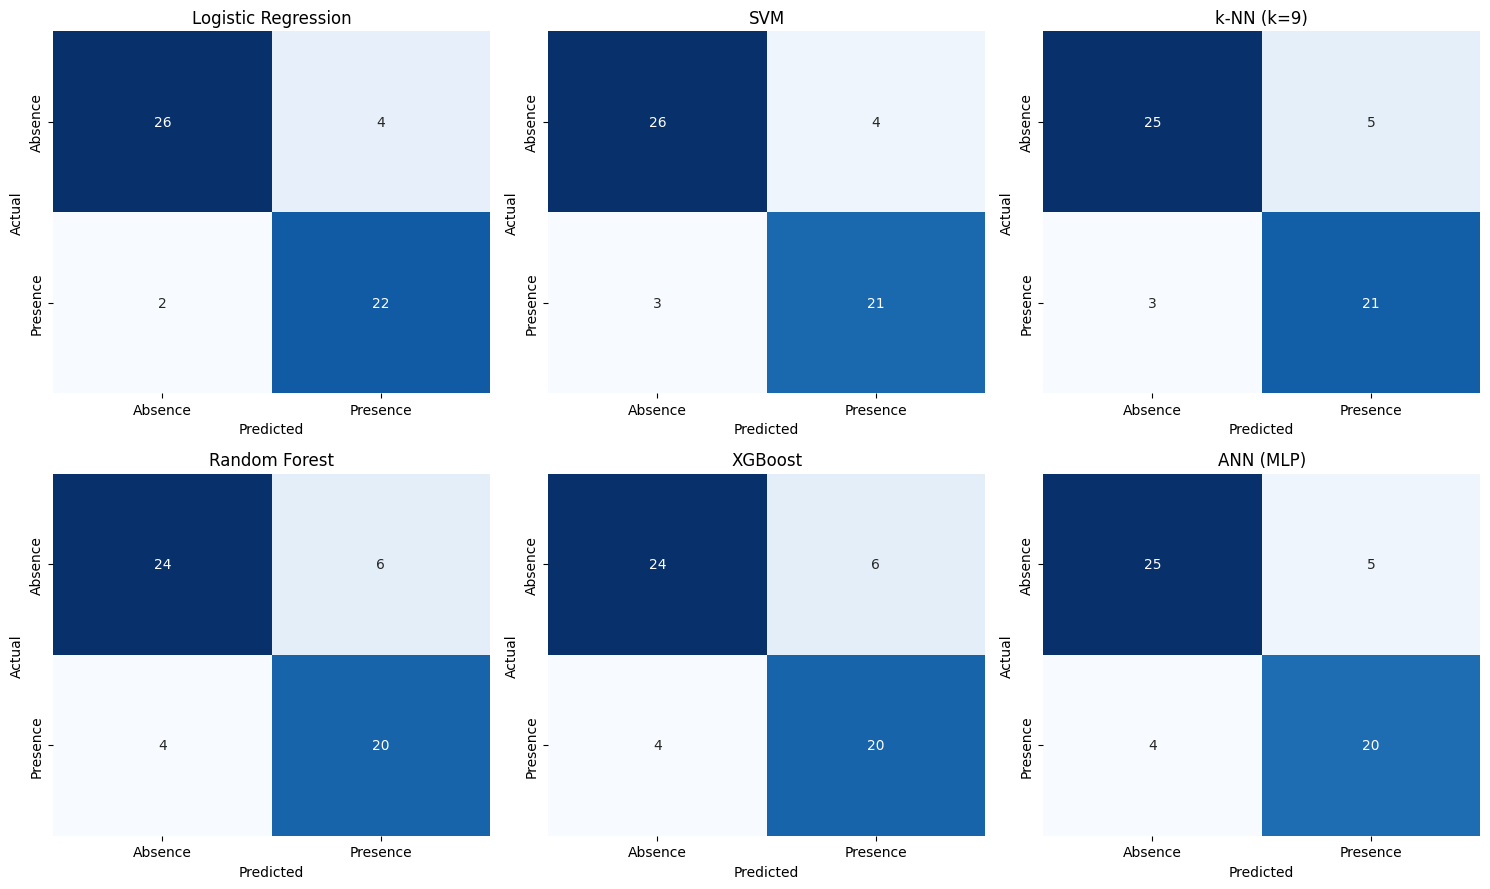

In [10]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Absence', 'Presence'], yticklabels=['Absence', 'Presence'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### ROC curves

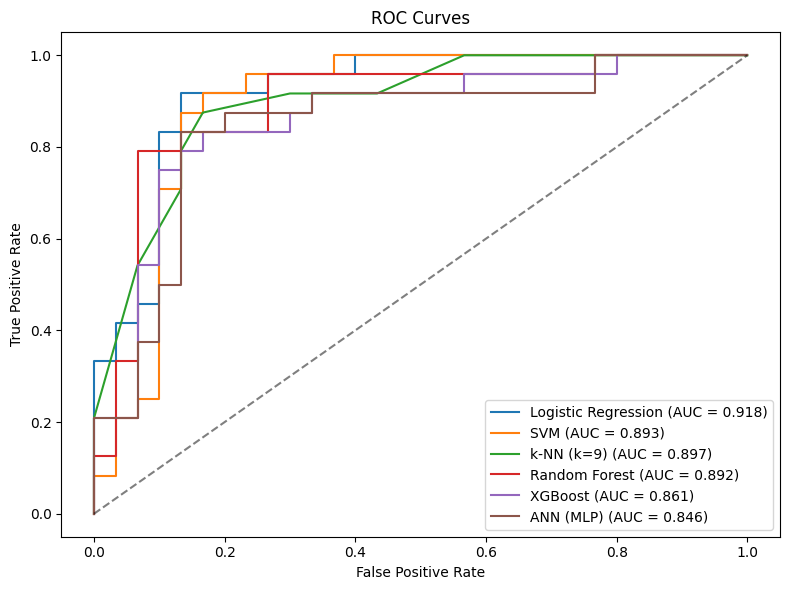

In [11]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

### Summary table

In [12]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
summary = pd.DataFrame({name: {m: res[m] for m in metric_cols}
                        for name, res in results.items()}).T.round(3)
summary = summary.sort_values('F1', ascending=False)
summary

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.889,0.846,0.917,0.880,0.918
SVM,0.870,0.840,0.875,0.857,0.893
k-NN (k=9),0.852,0.808,0.875,0.840,0.897
ANN (MLP),0.833,0.800,0.833,0.816,0.846
Random Forest,0.815,0.769,0.833,0.800,0.892
XGBoost,0.815,0.769,0.833,0.800,0.861


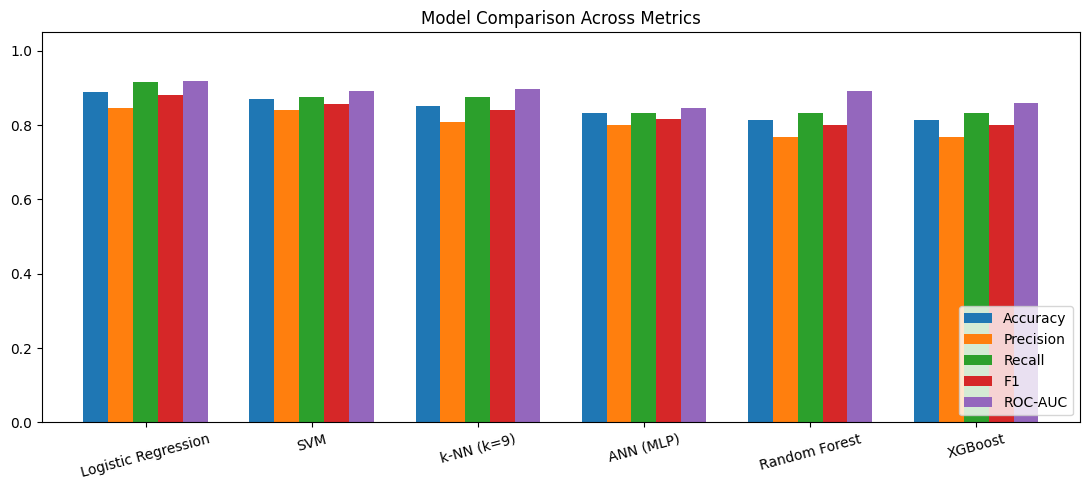

In [13]:
ax = summary[metric_cols].plot(kind='bar', figsize=(11, 5), rot=15, width=0.75)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison Across Metrics')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()